# Dataset description
### Population
**Source**: Departamento Administrativo Nacional de Estadística (DANE)

**Download**: [Banco de la república](https://suameca.banrep.gov.co/descarga-multiple-de-datos/)

### Births
**Source**: Departamento Administrativo Nacional de Estadística (DANE)

**Download**: [DANE](https://www.dane.gov.co/index.php/estadisticas-por-tema/salud/nacimientos-y-defunciones/nacimientos)

### Net migration
**Source**: World Bank

**Download**: [World Bank](https://data.worldbank.org/indicator/SM.POP.NETM?locations=CO)

## Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

## Code

In [ ]:
path_pop = "./data/population.csv"
path_mig = "./data/net_migration.csv"
path_bir = "./data/births_total.csv"

df_pop = pd.read_csv(path_pop, encoding="utf-8")
df_mig = pd.read_csv(path_mig, encoding="utf-8")
df_bir = pd.read_csv(path_bir, encoding="utf-8", usecols=[0,1])

df_pop["Fecha"] = pd.to_datetime(df_pop["Fecha"], dayfirst=True)
df_pop = df_pop[df_pop["Fecha"].dt.year > 2006]
df_pop["Fecha"] = df_pop["Fecha"].dt.year
df_pop["Población"] = df_pop["Población"].diff()
df_pop = df_pop.dropna()
df_pop.set_index("Fecha", inplace=True)
df_pop.rename(columns={"Población": "Population"}, inplace=True)

df_mig = df_mig[df_mig["Fecha"] > 2007]
df_mig.set_index("Fecha", inplace=True)

df_bir.set_index("year", inplace=True)
df_bir.rename(columns={"total_nacional": "Births"}, inplace=True)

df = pd.concat([df_pop, df_mig, df_bir], axis=1)

df = (df - df.min()) / (df.max() - df.min())

## Chart

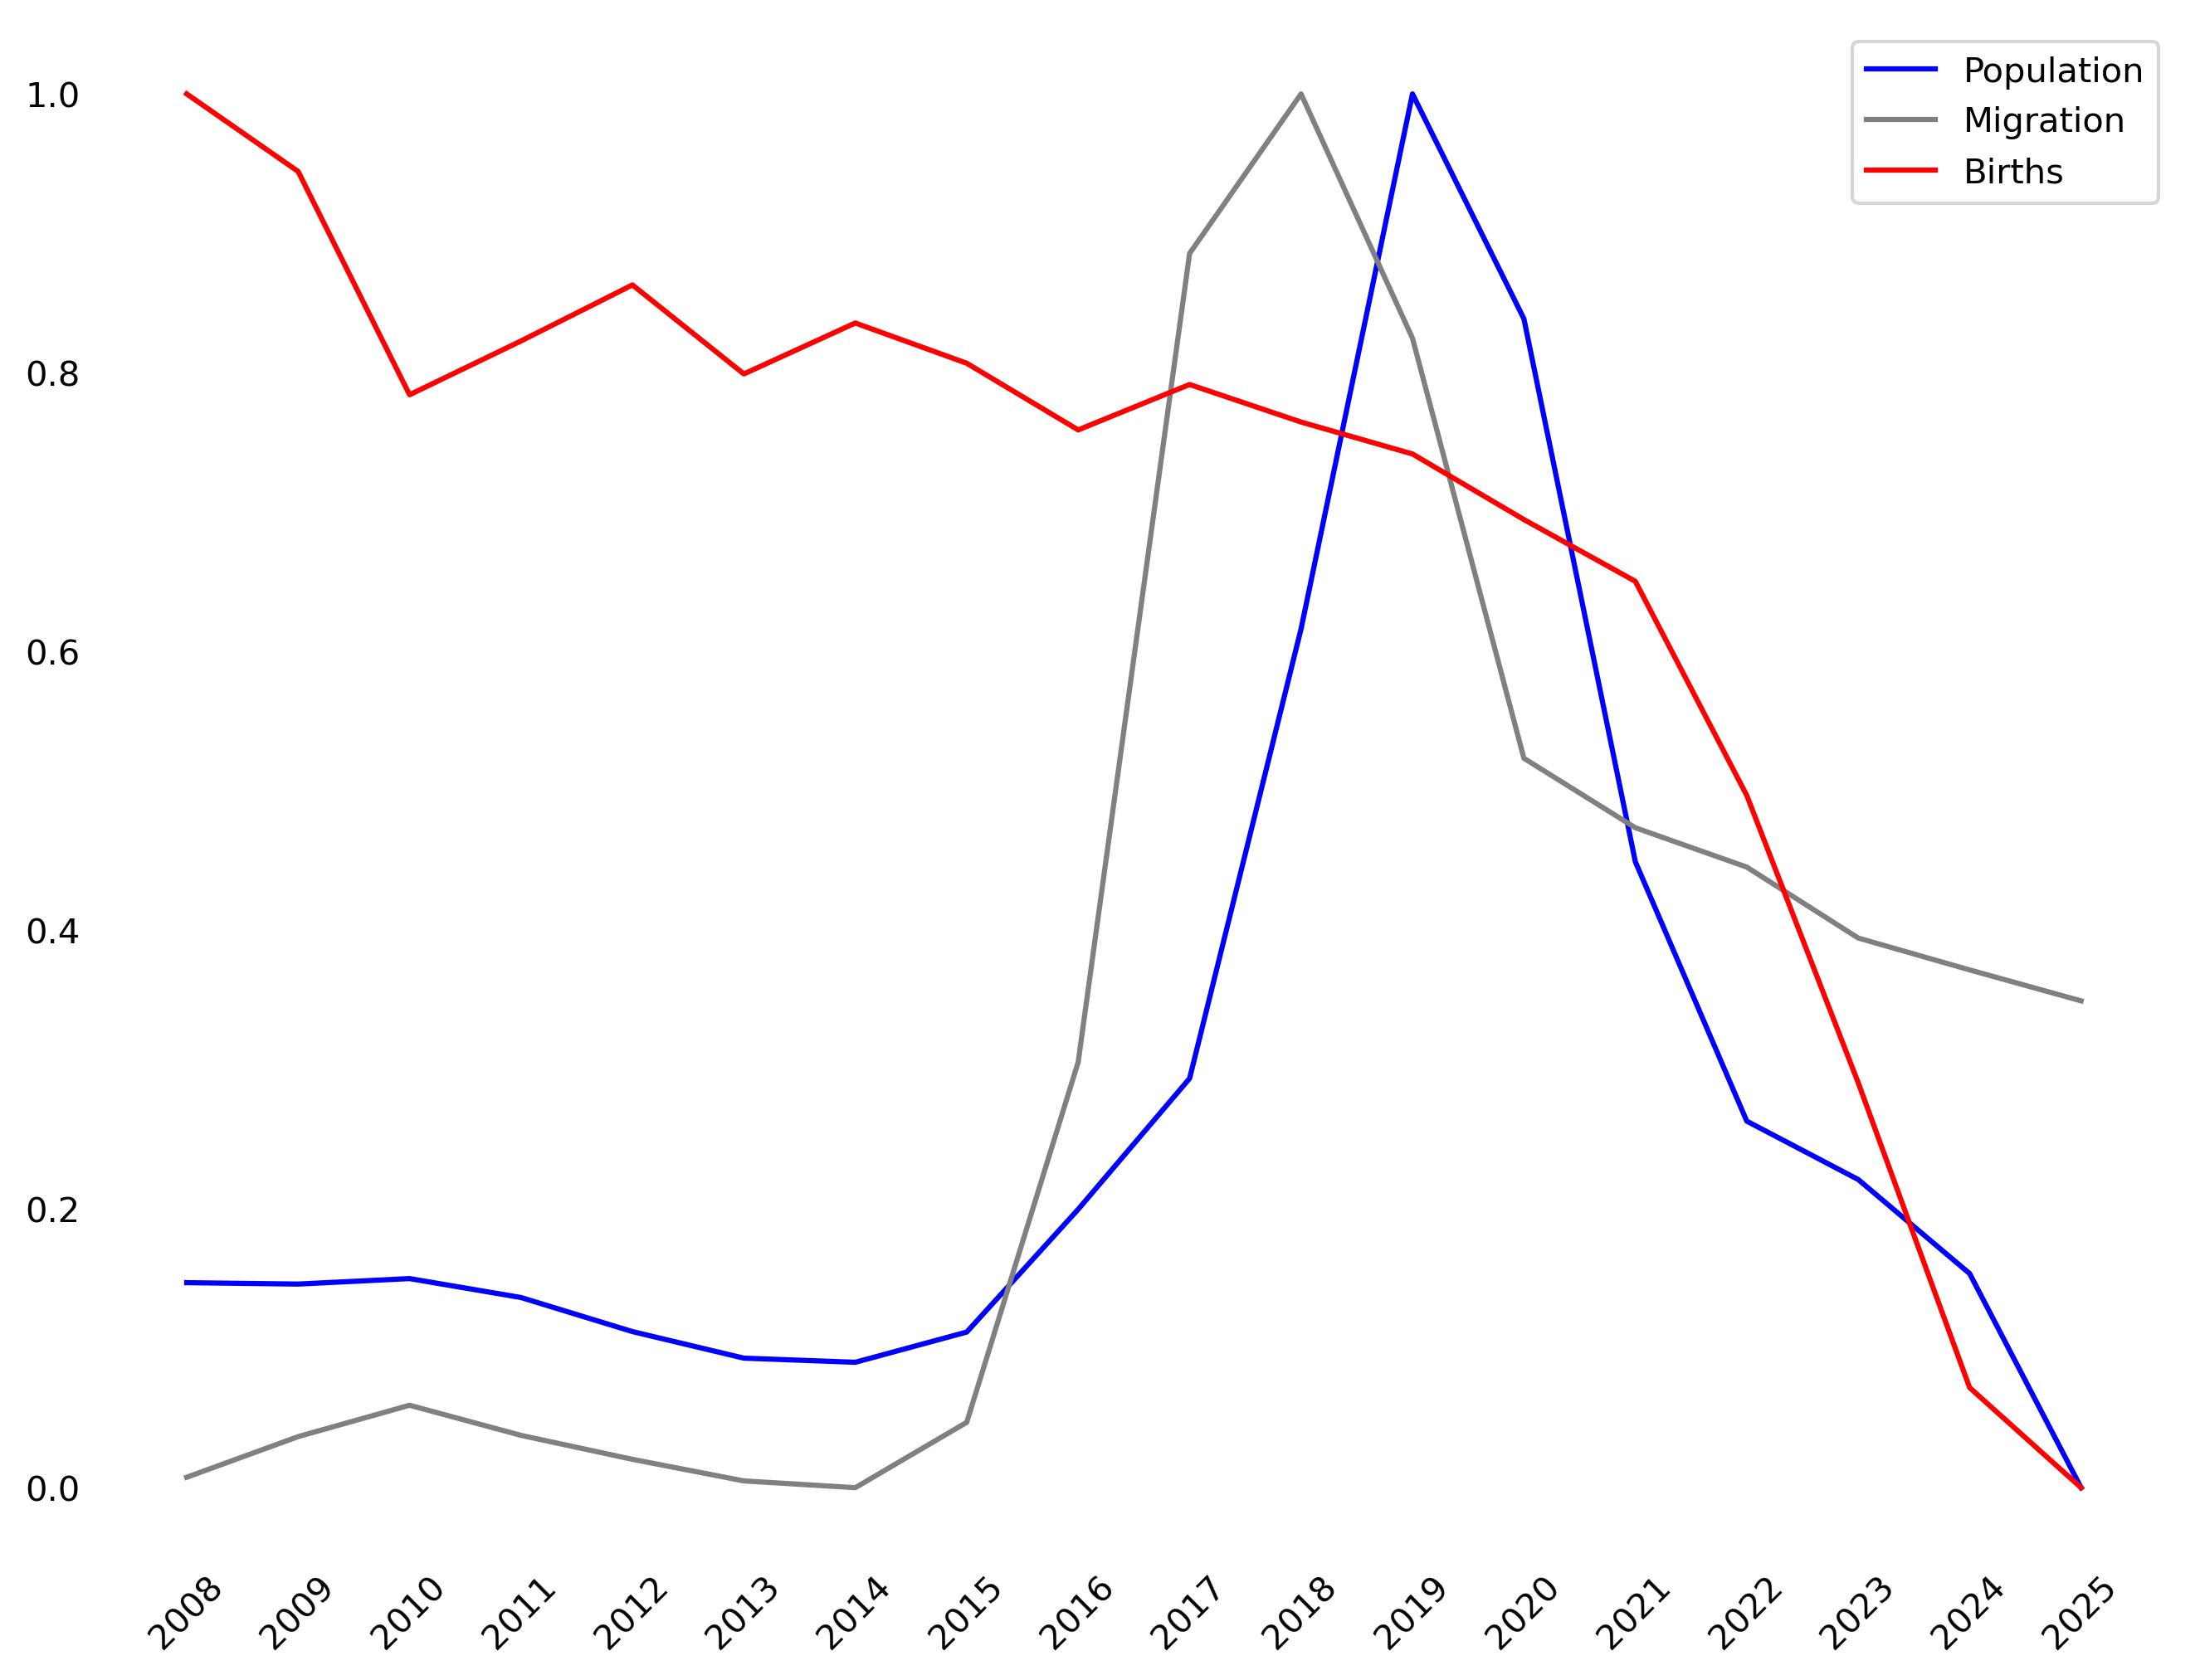

In [96]:
plt.figure(figsize=(10.8, 8), dpi=300)


for col, color in zip(df.columns, ["blue", "gray", "red"]):
    plt.plot(df[col], label=col, color=color)

plt.xticks(df.index, rotation=45)
plt.tick_params(axis="x", length=0)
plt.tick_params(axis="y", length=0)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.legend()

plt.show()